In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt

# %pip install -q git+https://github.com/osigaud/regressionLabs

from regression_labs.batch import Batch
from regression_labs.latent_function import (
    LinearLatentFunction,
    NonLinearLatentFunction,
    NonLinearLatentXDFunction,
)
from regression_labs.gaussians import Gaussians

from tqdm import tqdm, trange

In [13]:
class NewNonLinearLatentFunction:
    def __init__(self, seed: int = 0):
        self.rng = np.random.default_rng(seed)
        self.c0 = 2 * self.rng.uniform()
        self.c1 = 4 * self.rng.uniform()
        self.c2 = 4 * self.rng.uniform()
        self.c3 = 4 * self.rng.uniform()

    def generate_batch(
        self, size: int, noise: float = 0
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Every new batch is different
        """
        x = self.rng.uniform(size=size)
        y = self.latent_function(x)
        if noise != 0:
            y += self.rng.normal(scale=noise, size=size)
        return x.reshape(-1, 1), y

    def latent_function(self, x: np.ndarray):
        return (
            self.c0
            - x
            - np.sin(self.c1 * np.pi * x**3)
            * np.cos(self.c2 * np.pi * x**3)
            * np.exp(-(x**4))
        )

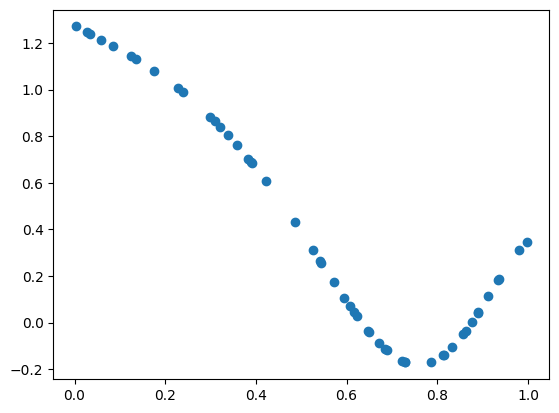

In [14]:
lf = NewNonLinearLatentFunction(seed=0)
x, y = lf.generate_batch(50)
plt.scatter(x, y)
plt.show()

## RBFN

We will choose to use Batch RBFN 2 as it seems to have been the most efficient method

Copied from notebook

In [15]:
color_map = [
    "yellow",
    "brown",
    "orange",
    "green",
    "cyan",
    "pink",
    "red",
    "blue",
    "black",
    "violet",
]


class RBFN(Gaussians):
    def __init__(self, nb_features):
        super().__init__(nb_features)
        self.theta = np.zeros(self.nb_features)

    def f(self, x):
        """
        Get the output of the function approximator for a given vector of input variables
        :param x: A vector of input variables of size N
        :return: A vector of function approximator outputs with size the number of x datapoints
        """
        f = np.dot(self.phi_output(x).transpose(), self.theta)
        return f

    def feature(self, x, idx):
        """
        Get the output of the idx^th feature for a given input vector
        This is function f() considering only one feature
        Used mainly for plotting the features

        :param x: A vector of dependent variables of size N
        :param idx: index of the feature

        :return: the value of the feature for x
        """
        phi = self.phi_output(x)
        return phi[idx] * self.theta[idx]

    # -- compute the residuals --#
    def compute_error(self, x_data, y_data):
        """
        Compute the residuals (squared sum of errors) over all the dataset
        :param x_data: the x values of datapoint
        :param y_data: the y values of datapoint

        :return: the residuals of the data given the model
        """
        error = ((y_data - self.f(x_data)) ** 2).sum()
        return error

    # ------ Plot function -------#
    def plot(self, x_data, y_data, title):
        """
        Given a dataset x_data, y_data, plots the points of the dataset,
        the feature functions multiplied by their weight parameter
        and the resulting model of the latent function
        :param x_data: the x values of datapoint
        :param y_data: the y values of datapoint

        :return: nothing
        """
        size = 500
        xs = np.linspace(0.0, 1.0, size)
        z = []
        for i in xs:
            z.append(self.f(np.array([i])))

        z2 = []
        for i in range(self.nb_features):
            temp = []
            for j in xs:
                temp.append(self.feature(np.array([j]), i))
            z2.append(temp)
            plt.plot(xs, z2[i], color=color_map[i % 10])
        plt.plot(x_data, y_data, "o", markersize=3, color="lightgreen")
        plt.plot(xs, z, lw=3, color="red")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(title)
        plt.show()


class BatchRBFN2(RBFN):
    def __init__(self, nb_features):
        super().__init__(nb_features)

    # ------ batch least squares (second perspective) ---------
    def train(self, x_data, y_data):
        # To be completed...
        G = self.phi_output(x_data).transpose()
        # Note that following formulas are equivalent to those from BatchRBFN1
        # (just matrix operations are developed)
        # the on;y important different - usage of pinv() instead of inv()
        A = np.sum([np.outer(phi, phi) for phi in G], axis=0)  # equivalently: G.T @ G
        b = G.T @ y_data
        self.theta = np.linalg.pinv(A) @ b

## LWR

Copied from notebook

In [16]:
def bar_design(x):
    return np.hstack((x, np.ones((x.shape[0], 1))))


class LWR(Gaussians):
    def __init__(self, nb_features):
        super().__init__(nb_features)
        # The first dimension is 2 because we assume the input is one-dimensional
        # So we just have two parameters per receptive field
        self.theta = np.zeros((2, self.nb_features))

    def f(self, x):
        """
        Get the output of the function approximator for a given vector of datapoints
        :param x: a single vector of N datapoints (each datapoint being of dimension d=1)
        :returns: a vector of N function approximator outputs
        """
        # wval = bar_design(x)
        # phi = self.phi_output(x)
        # linear_model = np.dot(wval, self.theta)
        # val = np.dot(linear_model, phi)
        # numerator = np.sum(val, axis=1)
        # return numerator / np.sum(phi, axis=0)
        weights = self.phi_output(x).T  # B x E
        lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
        weighted_sum = (lin_model * weights).sum(-1)  # tensor product
        sum_weights = weights.sum(-1)
        return weighted_sum / sum_weights

    def feature(self, x, idx):
        """
        Get the output of the idx^th feature for a given input variable(s)
        :param x: a single or vector of dependent variables with size [d] for which to calculate the features
        :param idx: index of the feature
        :returns: a vector of values
        """
        return np.dot(bar_design(x), self.theta[:, idx])

    # -- compute the residuals --#
    def compute_error(self, x_data, y_data):
        return ((y_data - self.f(x_data)) ** 2).sum()

    # ----------------------#
    # # Training Algorithm ##
    # ----------------------#

    def train(self, x_data, y_data) -> None:
        """
        Locally weighted least square function
        This code is specific to the 1D case
        :param x_data: a vector of x values
        :param y_data: a vector of y values
        :return: nothing (set the self.theta vector)
        """
        for k in range(self.nb_features):
            A = np.zeros((2, 2))
            b = np.zeros((2, 1))

            nb_points = x_data.shape[0]
            for i in range(nb_points):
                x_i = x_data[i].reshape(1, x_data.shape[1])
                y_i = y_data[i]

                phi = self.phi_output(x_i)

                # To be completed...
                x_i_bar = bar_design(x_i)
                A += phi[k] * (x_i_bar.T @ x_i_bar)
                b += phi[k] * (x_i_bar.T * y_i)

            result = np.dot(np.linalg.pinv(A), b)
            for i in range(2):
                self.theta[i, k] = result[i, 0]

    def plot(self, x_data, y_data, title):
        xs = np.linspace(0.0, 1.0, 1000)
        z = []
        for i in xs:
            val = self.f(np.array([[i]]))
            z.append(val)

        plt.plot(x_data, y_data, "o", markersize=3, color="lightgreen")
        plt.plot(xs, z, lw=2, color="red")
        for i in range(self.nb_features):
            ww = (1.0 - 0.0) / self.nb_features / 2.0
            xstmp = np.linspace(self.centers[i] - ww, self.centers[i] + ww, 100)

            z2 = []
            for j in xstmp:
                z2.append(self.feature(np.array([[j]]), i))
            plt.plot(xstmp, z2, lw=2, color="blue", ls="-")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(title)
        plt.show()

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3662537500.py:99: RuntimeWarning: divide by zero encountered in matmul
  b = G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3662537500.py:99: RuntimeWarning: overflow encountered in matmul
  b = G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3662537500.py:99: RuntimeWarning: invalid value encountered in matmul
  b = G.T @ y_data


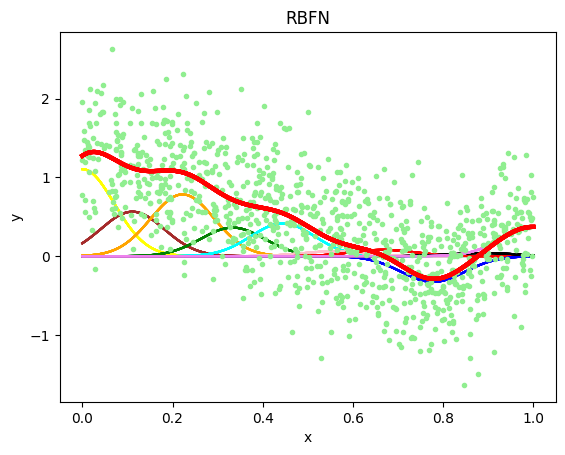

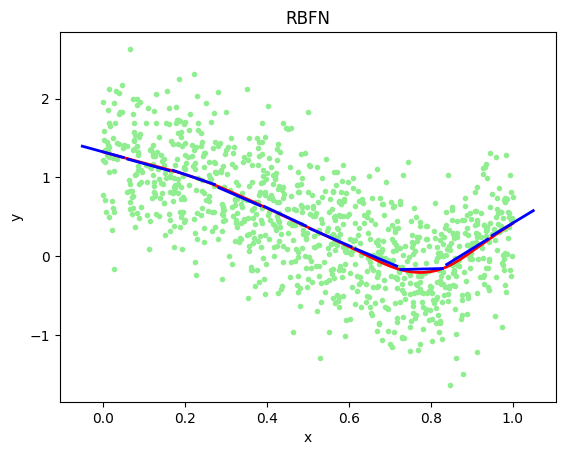

RBFN Mean Error 0.2583480022257088
LWR Mean Error 0.26007434407742036


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3364165843.py:25: RuntimeWarning: divide by zero encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3364165843.py:25: RuntimeWarning: overflow encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3364165843.py:25: RuntimeWarning: invalid value encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E


In [17]:
lf = NewNonLinearLatentFunction()
size = 1000
x, y = lf.generate_batch(size, 0.5)
model_rbfn = BatchRBFN2(10)
model_rbfn.train(x, y)
model_rbfn.plot(x, y, "RBFN")
model_lwr = LWR(10)
model_lwr.train(x, y)
model_lwr.plot(x, y, "RBFN")
print(f"RBFN Mean Error {model_rbfn.compute_error(x, y) / size}")
print(f"LWR Mean Error {model_lwr.compute_error(x, y) / size}")

In [18]:
lf = NewNonLinearLatentFunction()
x, y = lf.generate_batch(100)

## NN

In [19]:
import torch as th
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [20]:
class NeuralNetwork(nn.Module):
    def __init__(self, l1, l2, l3, l4, out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(l1, l2),
            nn.ReLU(),
            nn.Linear(l2, l3),
            nn.ReLU(),
            nn.Linear(l3, l4),
            nn.ReLU(),
            nn.Linear(l4, out),
        )

    def forward(self, x):
        return self.net(x)

In [21]:
learning_rate = 5e-2
epochs = 500

input_model = NeuralNetwork(1, 10, 10, 10, 1)
optimizer = th.optim.Adam(input_model.parameters(), lr=learning_rate)
mse_loss = nn.MSELoss()

lf = NewNonLinearLatentFunction(seed=0)
x, y = lf.generate_batch(1000, 0.1)

x = th.tensor(x, dtype=th.float32).reshape(-1, 1)
y = th.tensor(y, dtype=th.float32).reshape(-1, 1)

dataset = TensorDataset(x, y)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)


def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    size = len(dataloader.dataset)

    seen = 0
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        seen += X.size(0)
        if batch % 100 == 0:
            print(f"loss: {loss.item():.6f}  [{seen:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0.0

    with th.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    print(f"Test MSE: {test_loss:.6f}\n")
    return test_loss


for t in range(epochs):  # , desc="Epochs"):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_loop(dataloader, input_model, mse_loss, optimizer)
    test_loop(dataloader, input_model, mse_loss)

print("Done!")

Epoch 1
-------------------------------
loss: 0.219032  [    1/ 1000]
loss: 0.060350  [  101/ 1000]
loss: 0.028027  [  201/ 1000]
loss: 0.040244  [  301/ 1000]
loss: 0.036674  [  401/ 1000]
loss: 0.007709  [  501/ 1000]
loss: 0.097111  [  601/ 1000]
loss: 0.048027  [  701/ 1000]
loss: 0.014915  [  801/ 1000]
loss: 0.074692  [  901/ 1000]
Test MSE: 0.065266

Epoch 2
-------------------------------
loss: 0.005514  [    1/ 1000]
loss: 0.206936  [  101/ 1000]
loss: 0.044560  [  201/ 1000]
loss: 0.029983  [  301/ 1000]
loss: 0.011938  [  401/ 1000]
loss: 0.000034  [  501/ 1000]
loss: 0.000106  [  601/ 1000]
loss: 0.021026  [  701/ 1000]
loss: 0.002980  [  801/ 1000]
loss: 0.000095  [  901/ 1000]
Test MSE: 0.026787

Epoch 3
-------------------------------
loss: 0.011293  [    1/ 1000]
loss: 0.028126  [  101/ 1000]
loss: 0.133851  [  201/ 1000]
loss: 0.000058  [  301/ 1000]
loss: 0.000142  [  401/ 1000]
loss: 0.000507  [  501/ 1000]
loss: 0.016472  [  601/ 1000]
loss: 0.001478  [  701/ 1000]


In [22]:
for X, y in dataloader:
    print(X)
    print(y)
    print("Hit")

tensor([[0.4392]])
tensor([[0.7875]])
Hit
tensor([[0.7441]])
tensor([[-0.1820]])
Hit
tensor([[0.0145]])
tensor([[1.2850]])
Hit
tensor([[0.1982]])
tensor([[1.1761]])
Hit
tensor([[0.0714]])
tensor([[1.1265]])
Hit
tensor([[0.7308]])
tensor([[-0.2074]])
Hit
tensor([[0.6687]])
tensor([[-0.1179]])
Hit
tensor([[0.3833]])
tensor([[0.6153]])
Hit
tensor([[0.7993]])
tensor([[-0.2638]])
Hit
tensor([[0.0674]])
tensor([[1.1007]])
Hit
tensor([[0.6505]])
tensor([[-0.1372]])
Hit
tensor([[0.2647]])
tensor([[0.9544]])
Hit
tensor([[0.4294]])
tensor([[0.6088]])
Hit
tensor([[0.8236]])
tensor([[-0.0992]])
Hit
tensor([[0.0889]])
tensor([[1.2485]])
Hit
tensor([[0.8369]])
tensor([[0.0012]])
Hit
tensor([[0.1671]])
tensor([[1.0896]])
Hit
tensor([[0.9819]])
tensor([[0.2596]])
Hit
tensor([[0.9398]])
tensor([[0.1303]])
Hit
tensor([[0.3180]])
tensor([[0.7801]])
Hit
tensor([[0.7698]])
tensor([[-0.1951]])
Hit
tensor([[0.6267]])
tensor([[-0.0390]])
Hit
tensor([[0.1874]])
tensor([[0.9631]])
Hit
tensor([[0.8144]])
tensor(

In [24]:
def plot_data_and_model(model, x, y, n_points=1000):
    """
    x, y: tensors shaped (N, 1) on CPU (or at least plottable)
    """
    model.eval()
    with th.no_grad():
        # sort x for a nice line plot
        x_sorted, idx = th.sort(x.squeeze(1))
        y_sorted = y.squeeze(1)[idx]

        # dense grid over the observed x-range
        x_grid = th.linspace(x_sorted.min(), x_sorted.max(), n_points).unsqueeze(1)

        # model predictions
        y_pred = model(x_grid).squeeze(1)

    # plotting
    plt.figure()
    plt.scatter(x_sorted.numpy(), y_sorted.numpy(), s=10, alpha=0.6, label="data")
    plt.plot(
        x_grid.squeeze(1).numpy(), y_pred.numpy(), linewidth=2, label="model", c="red"
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


plot_data_and_model(input_model, x, y)

IndexError: index 851 is out of bounds for dimension 0 with size 1

## Evaluation

In [25]:
# We will always be evaluating on these sizes and noises
sizes = [100, 250, 500, 1000, 2000, 5000]
noises = np.linspace(0.00, 0.5, 10)

In [ ]:
def evaluate_model(
    input_model: BatchRBFN2 | LWR,
    sizes: list[int],
    noises: list[float],
    n_features: int = 10,
    n_samples: int = 5,
    generalization = False
):
    res = {}
    for noise in tqdm(noises):
        for size in sizes:
            errors = np.empty(n_samples)
            train_times = np.empty(n_samples)
            for i in range(n_samples):
                lf = NewNonLinearLatentFunction(seed=i)
                x, y = lf.generate_batch(size, noise)
                model = input_model(n_features)
                train_start = time.process_time()
                model.train(x, y)
                train_time = time.process_time() - train_start
                if generalization:
                    y = lf.latent_function(x)
                error = (1 / size) * model.compute_error(x, y)
                errors[i] = error
                train_times[i] = train_time
            res[(size, noise)] = (errors / size, train_times)
    return res

In [47]:
# Approximately 2.5 seconds
rbfn_evaluation = evaluate_model(BatchRBFN2, sizes, noises, generalization=False)

  0%|          | 0/10 [00:00<?, ?it/s]/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3662537500.py:99: RuntimeWarning: divide by zero encountered in matmul
  b = G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3662537500.py:99: RuntimeWarning: overflow encountered in matmul
  b = G.T @ y_data
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3662537500.py:99: RuntimeWarning: invalid value encountered in matmul
  b = G.T @ y_data
100%|██████████| 10/10 [00:00<00:00, 11.30it/s]


In [48]:
# ~25 seconds
lwr_evaluation = evaluate_model(LWR, sizes, noises, generalization=False)

  0%|          | 0/10 [00:00<?, ?it/s]/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3364165843.py:25: RuntimeWarning: divide by zero encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3364165843.py:25: RuntimeWarning: overflow encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_97455/3364165843.py:25: RuntimeWarning: invalid value encountered in matmul
  lin_model = bar_design(x) @ self.theta  # B x 2 @ 2 x E = B x E
100%|██████████| 10/10 [00:31<00:00,  3.13s/it]


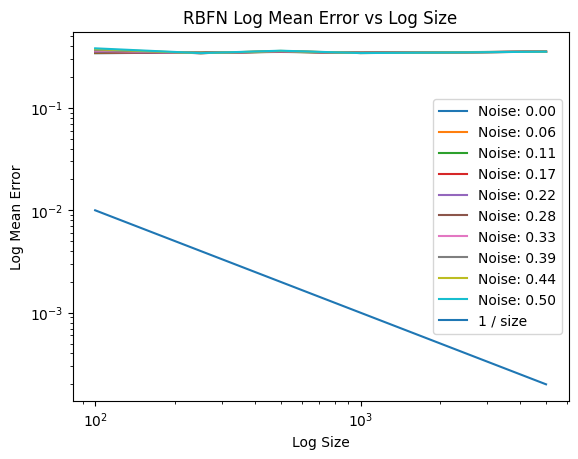

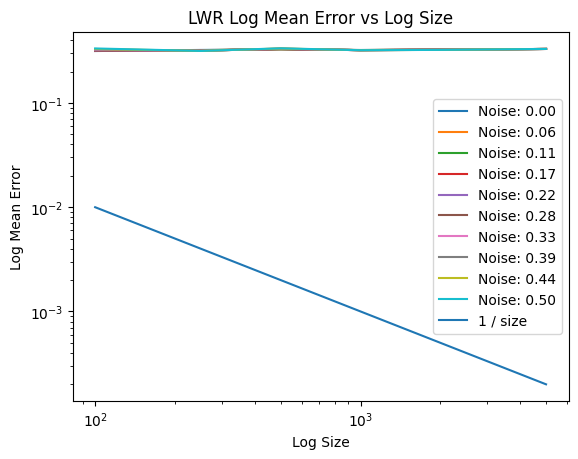

In [43]:
def plot_mean_error_vs_size(model_name, evaluation):
    for noise in noises:
        errors = [evaluation[size, noise][0] for size in sizes]
        mean_errors = np.array([error.mean() for error in errors])
        # std_errors = np.array([error.m])
        plt.loglog(sizes, mean_errors, label=f"Noise: {noise:.2f}")
    plt.loglog(np.array(sizes), np.array(sizes) ** (-1.0), label="1 / size")
    plt.title(f"{model_name} Log Mean Error vs Log Size")
    plt.xlabel("Log Size")
    plt.ylabel("Log Mean Error")
    plt.legend()
    plt.show()


plot_mean_error_vs_size("RBFN", rbfn_evaluation)
plot_mean_error_vs_size("LWR", lwr_evaluation)

In [30]:
def evaluate_nn(sizes: list[int], noises: list[float], n_samples: int = 1):
    learning_rate = 5e-2
    epochs = 3500
    mse_loss = nn.MSELoss()
    res = {}

    for noise in tqdm(noises):
        for size in sizes:
            errors = np.empty(n_samples)
            train_times = np.empty(n_samples)

            for i in range(n_samples):
                th.manual_seed(i)
                lf = NewNonLinearLatentFunction(seed=i)
                x, y = lf.generate_batch(size, noise)
                x = th.tensor(x, dtype=th.float32).reshape(-1, 1)
                y = th.tensor(y, dtype=th.float32).reshape(-1, 1)
                dataset = TensorDataset(x, y)
                dataloader = DataLoader(dataset, batch_size=size, shuffle=True)

                model = NeuralNetwork(1, 10, 10, 10, 1)
                optimizer = th.optim.Adam(model.parameters(), lr=learning_rate)

                train_start = time.process_time()
                # Train the model
                for t in range(epochs):
                    train_loop(dataloader, model, mse_loss, optimizer)
                train_time = time.process_time() - train_start

                # Evaluate
                error = test_loop(dataloader, model, mse_loss)

                errors[i] = error
                train_times[i] = train_time

            res[(size, noise)] = (errors, train_times)

    return res

In [36]:
nn_evaluation = evaluate_nn(sizes, noises)

  0%|          | 0/10 [00:00<?, ?it/s]

loss: 0.415684  [  100/  100]
loss: 0.271464  [  100/  100]
loss: 0.267340  [  100/  100]
loss: 0.260489  [  100/  100]
loss: 0.223676  [  100/  100]
loss: 0.208762  [  100/  100]
loss: 0.205773  [  100/  100]
loss: 0.203468  [  100/  100]
loss: 0.195300  [  100/  100]
loss: 0.181250  [  100/  100]
loss: 0.166456  [  100/  100]
loss: 0.154412  [  100/  100]
loss: 0.141357  [  100/  100]
loss: 0.118256  [  100/  100]
loss: 0.091774  [  100/  100]
loss: 0.070156  [  100/  100]
loss: 0.047182  [  100/  100]
loss: 0.025552  [  100/  100]
loss: 0.019051  [  100/  100]
loss: 0.021060  [  100/  100]
loss: 0.029864  [  100/  100]
loss: 0.043204  [  100/  100]
loss: 0.044411  [  100/  100]
loss: 0.039760  [  100/  100]
loss: 0.031512  [  100/  100]
loss: 0.022075  [  100/  100]
loss: 0.018225  [  100/  100]
loss: 0.017587  [  100/  100]
loss: 0.017742  [  100/  100]
loss: 0.019325  [  100/  100]
loss: 0.020863  [  100/  100]
loss: 0.021199  [  100/  100]
loss: 0.021390  [  100/  100]
loss: 0.02

  0%|          | 0/10 [00:05<?, ?it/s]

loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011804  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.011803  [  500/  500]
loss: 0.01

KeyboardInterrupt: 

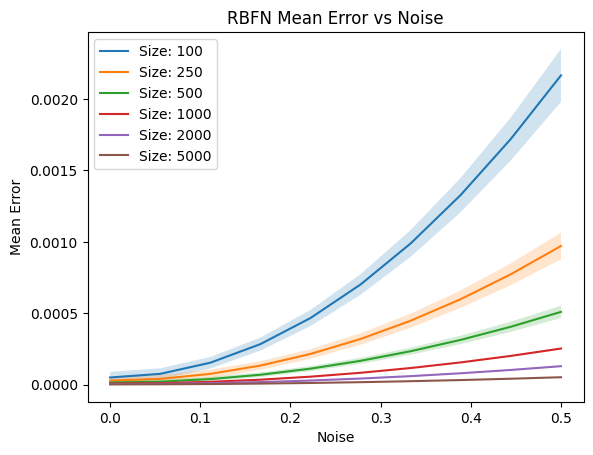

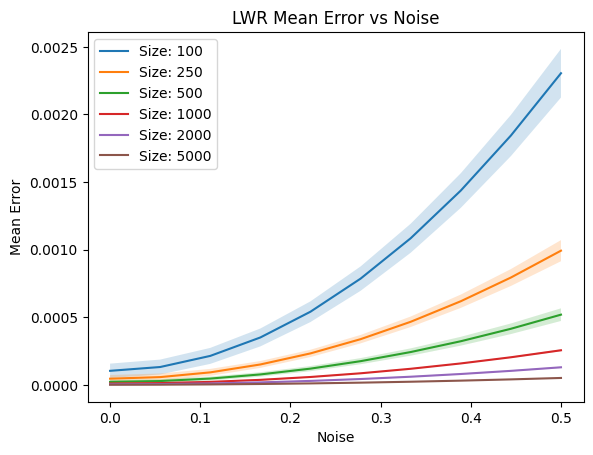

In [49]:
def plot_mean_error_vs_noise(model_name, evaluation, saveto=None):
    for size in sizes:
        errors = [evaluation[size, noise][0] for noise in noises]
        mean_errors = np.array([error.mean() for error in errors])
        std_mean_errors = np.array([error.std() for error in errors])
        plt.plot(noises, mean_errors, label=f"Size: {size}")
        plt.fill_between(
            noises,
            mean_errors - std_mean_errors,
            mean_errors + std_mean_errors,
            alpha=0.2,
        )
    plt.title(f"{model_name} Mean Error vs Noise")
    plt.xlabel("Noise")
    plt.ylabel("Mean Error")
    plt.legend()
    if saveto:
        plt.savefig(saveto)
    plt.show()


plot_mean_error_vs_noise("RBFN", rbfn_evaluation)
plot_mean_error_vs_noise("LWR", lwr_evaluation)
# plot_mean_error_vs_noise("NN", nn_evaluation)

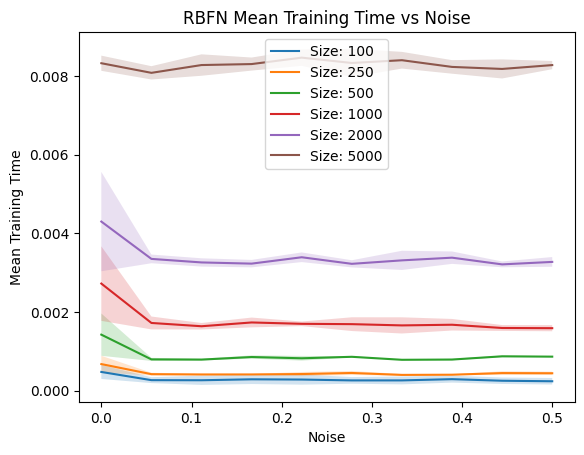

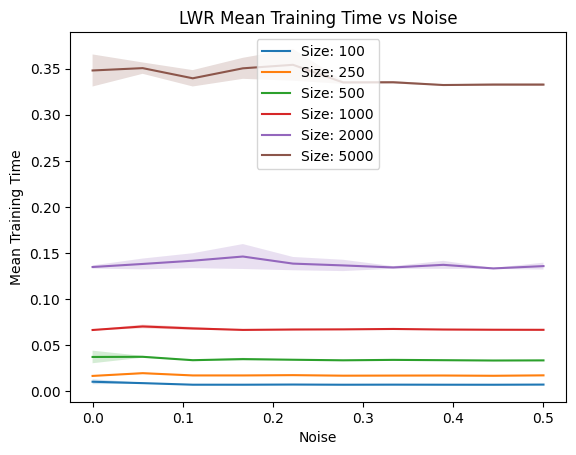

In [46]:
def plot_mean_training_time_vs_noise(model_name, evaluation):
    for size in sizes:
        training_times = [evaluation[size, noise][1] for noise in noises]
        mean_training_times = np.array(
            [training_time.mean() for training_time in training_times]
        )
        std_training_times = np.array(
            [training_time.std() for training_time in training_times]
        )
        plt.plot(noises, mean_training_times, label=f"Size: {size}")
        plt.fill_between(
            noises,
            mean_training_times - std_training_times,
            mean_training_times + std_training_times,
            alpha=0.2,
        )
    plt.title(f"{model_name} Mean Training Time vs Noise")
    plt.xlabel("Noise")
    plt.ylabel("Mean Training Time")
    plt.legend()
    plt.show()


plot_mean_training_time_vs_noise("RBFN", rbfn_evaluation)
plot_mean_training_time_vs_noise("LWR", lwr_evaluation)
# plot_mean_training_time_vs_noise("NN", nn_evaluation)

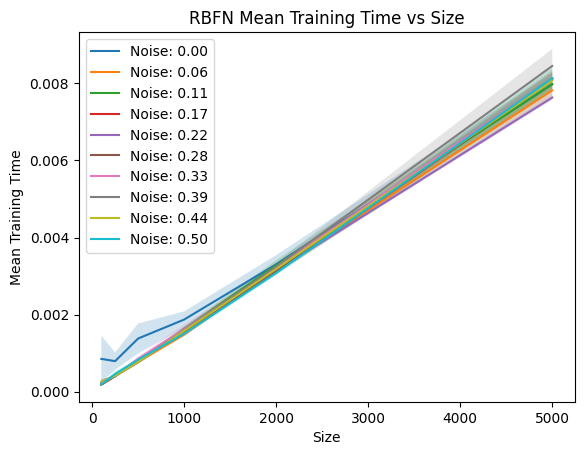

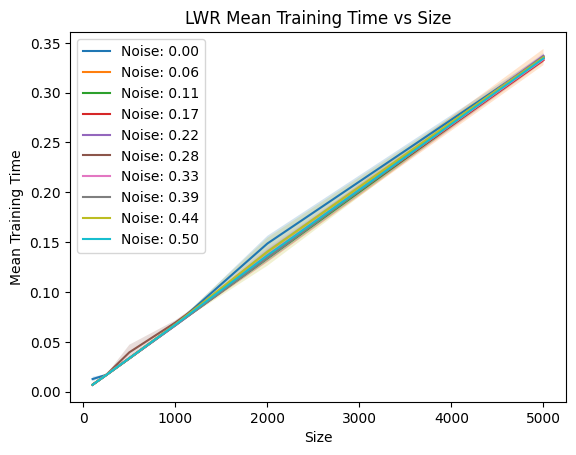

In [ ]:
def plot_mean_training_time_vs_size(model_name, evaluation):
    for noise in noises:
        errors = [evaluation[size, noise][1] for size in sizes]
        mean_errors = np.array([error.mean() for error in errors])
        std_errors = np.array([error.std() for error in errors])
        plt.plot(sizes, mean_errors, label=f"Noise: {noise:.2f}")
        plt.fill_between(
            sizes, mean_errors - std_errors, mean_errors + std_errors, alpha=0.2
        )
    plt.title(f"{model_name} Mean Training Time vs Size")
    plt.xlabel("Size")
    plt.ylabel("Mean Training Time")
    plt.legend()
    plt.show()


plot_mean_training_time_vs_size("RBFN", rbfn_evaluation)
plot_mean_training_time_vs_size("LWR", lwr_evaluation)
plot_mean_training_time_vs_size("NN", nn_evaluation)